In [2]:
from google.colab import files
uploaded = files.upload()

Saving cardio_train.csv to cardio_train.csv


In [6]:
import pandas as pd

df = pd.read_csv('/content/cardio_train.csv', sep=';')

In [7]:
!pip install tensorflow seaborn

Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Loading Datasets

In [10]:
df = pd.read_csv('cardio_train.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Data Preprocessing

In [11]:
# Convert age
df['age'] = (df['age'] / 365).astype(int)

# Remove outliers
df = df[(df['ap_hi'] < 200) & (df['ap_hi'] > 80)]
df = df[(df['ap_lo'] < 150) & (df['ap_lo'] > 40)]

# Drop ID
df.drop('id', axis=1, inplace=True)

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


Exploratory Data Analysis (EDA)

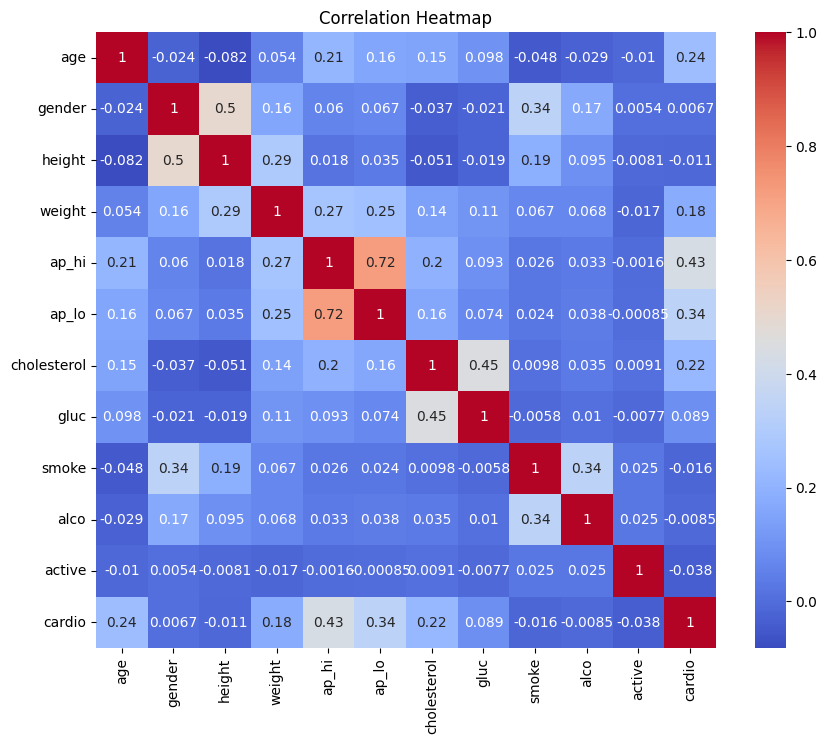

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Features & Split

In [15]:
X = df.drop('cardio', axis=1)
y = df['cardio']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scaling

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression

In [17]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Decision Tree

In [18]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [20]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

ANN

In [21]:
ann = Sequential()

ann.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=10, batch_size=32)

y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.7132 - loss: 0.5729
Epoch 2/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7274 - loss: 0.5522
Epoch 3/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7283 - loss: 0.5496
Epoch 4/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7289 - loss: 0.5482
Epoch 5/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7283 - loss: 0.5475
Epoch 6/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7295 - loss: 0.5467
Epoch 7/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7292 - loss: 0.5461
Epoch 8/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7294 - loss: 0.5457
Epoch 9/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7304 - loss: 0.5454
Epoch 10/10
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7302 - loss: 0.5450
428/428 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


Evaluation

In [22]:
def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_ann, "ANN")


Logistic Regression
Accuracy: 0.7296093464768164
Precision: 0.7593520374081496
Recall: 0.6677926274049053
F1 Score: 0.7106353051496445

Decision Tree
Accuracy: 0.7313618108798832
Precision: 0.7847525473071325
Recall: 0.6334263474812748
F1 Score: 0.7010158472165786

Random Forest
Accuracy: 0.7107703541438481
Precision: 0.7124105011933174
Recall: 0.7014245851079454
F1 Score: 0.7068748612447273

ANN
Accuracy: 0.7367652427893392
Precision: 0.7521246458923513
Recall: 0.7018651784402996
F1 Score: 0.7261262630099521


Confusion Matrix

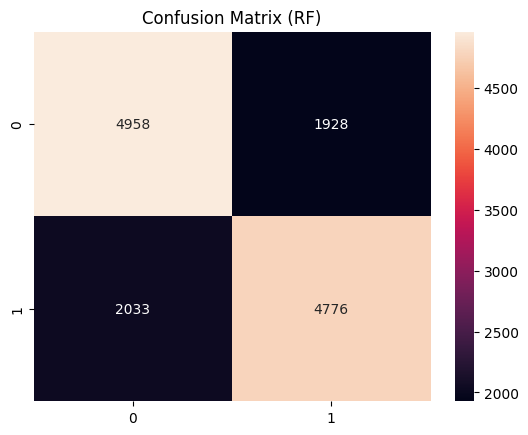

In [23]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (RF)")
plt.show()

ROC Curve

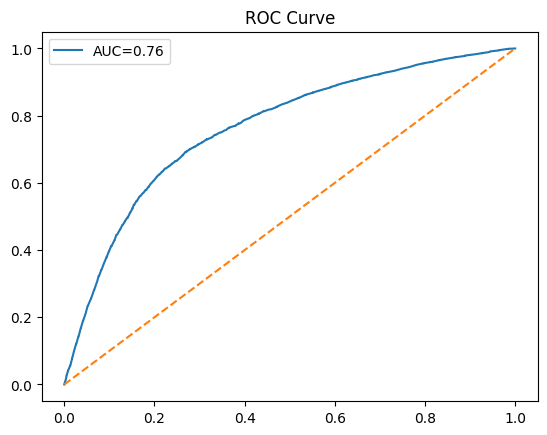

In [24]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

Target Distribution

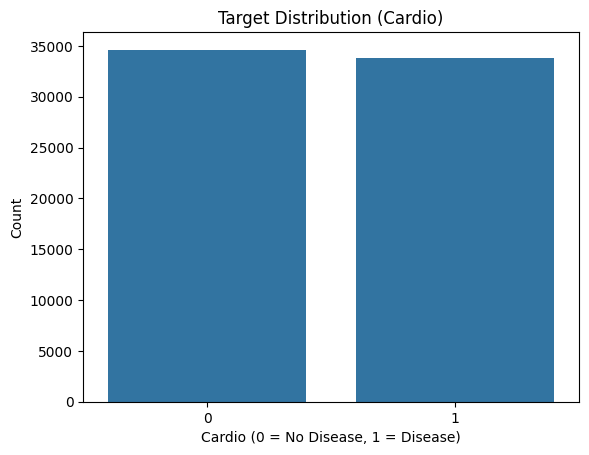

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='cardio', data=df)
plt.title("Target Distribution (Cardio)")
plt.xlabel("Cardio (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

Comparison Table

In [25]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['LR','DT','RF','ANN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ann)
    ]
})

results

,Model,Accuracy
0,LR,0.729609
1,DT,0.731362
2,RF,0.710770
3,ANN,0.736765
